# Chicago Crime Dataset — Exploratory Data Analysis

**Objective:** Understand the dataset structure, assess data quality, and extract meaningful insights about crime patterns in Chicago.

## 1. Data Overview

First, load the data and get a basic sense of its shape, column types, and summary statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('chicago_crime_dataset.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 12539 rows, 23 columns


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year
0,13733090,JJ130321,01/28/2025 3:30:00 PM,076XX S RACINE AVE,560,ASSAULT,SIMPLE,STREET,False,False,612,6,17,71,08A,1169643.0,1854247.0,2025,05/17/2025 3:40:52 PM,41.755554,-87.653868,"(41.755554244, -87.653867946)",2025
1,13909076,JJ344224,07/22/2025 12:40:00 PM,011XX W THORNDALE AVE,560,ASSAULT,SIMPLE,TAVERN / LIQUOR STORE,True,False,2433,24,48,77,08A,1167566.0,1939682.0,2025,03/14/2026 3:41:39 PM,41.990039,-87.659020,"(41.990039445, -87.659019968)",2025
2,13101860,JG295014,06/09/2023 8:23:00 PM,008XX S KOLMAR AVE,1507,PROSTITUTION,SOLICIT OFF PUBLIC WAY,STREET,True,False,1131,11,24,26,16,1146144.0,1895827.0,2023,08/19/2023 3:40:26 PM,41.870133,-87.738933,"(41.870133029, -87.738933006)",2023
3,13701134,JH553823,12/24/2024 5:38:00 AM,043XX N KIMBALL AVE,910,MOTOR VEHICLE THEFT,AUTOMOBILE,CONVENIENCE STORE,False,False,1723,17,33,16,7,1152935.0,1928827.0,2024,11/02/2025 3:41:09 PM,41.960556,-87.713125,"(41.96055619, -87.71312483)",2024
4,13967696,JJ415709,09/15/2025 3:20:00 PM,004XX S WESTERN AVE,312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,CTA TRAIN,True,False,1135,11,28,28,3,1160478.0,1897788.0,2025,03/14/2026 3:41:39 PM,41.875230,-87.686254,"(41.875229772, -87.686253982)",2025


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12539 entries, 0 to 12538
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    12539 non-null  int64  
 1   Case Number           12539 non-null  str    
 2   Date                  12539 non-null  str    
 3   Block                 12539 non-null  str    
 4   IUCR                  12539 non-null  str    
 5   Primary Type          12539 non-null  str    
 6   Description           12539 non-null  str    
 7   Location Description  12491 non-null  str    
 8   Arrest                12539 non-null  bool   
 9   Domestic              12539 non-null  bool   
 10  Beat                  12539 non-null  int64  
 11  District              12539 non-null  int64  
 12  Ward                  12539 non-null  int64  
 13  Community Area        12539 non-null  int64  
 14  FBI Code              12539 non-null  str    
 15  X Coordinate          12361 no

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,12539.0,NaN,NaN,NaN,13145705.180876,950903.201597,25735.0,12746008.5,13199884.0,13649192.5,14269471.0
Case Number,12539,12539,JJ130321,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,12539,12318,06/01/2022 12:00:00 AM,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Block,12539,7990,001XX N STATE ST,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IUCR,12539,249,486,1078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Primary Type,12539,28,THEFT,2513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,12539,233,SIMPLE,1366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location Description,12491,101,STREET,3522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrest,12539,2,False,8335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domestic,12539,2,False,10150,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Fixing data types

Before going further, two issues from the overview above need fixing:

1. **`Date` is stored as a string** — we can't extract hour/day/month or sort chronologically until it's a real `datetime`.
2. **`District`, `Ward`, `Community Area`, `Beat` are numeric codes, not quantities** — averaging them is meaningless, so we convert them to `category` type.

In [4]:
# Convert Date to actual datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

# Convert location codes to categorical (they're labels, not quantities)
cat_cols = ['District', 'Ward', 'Community Area', 'Beat', 'IUCR', 'FBI Code']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(df['Date'].dtype)
print(df[cat_cols].dtypes)

datetime64[us]
District          category
Ward              category
Community Area    category
Beat              category
IUCR              category
FBI Code          category
dtype: object


## 2. Missing Value Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
X Coordinate,178,1.42
Y Coordinate,178,1.42
Longitude,178,1.42
Latitude,178,1.42
Location,178,1.42
Location Description,48,0.38


**Is the missingness random, or concentrated somewhere?**

Rather than assume, check whether missing coordinates cluster around specific `Primary Type` or `Location Description` values. If yes, that itself is a data quality insight worth reporting. If missingness is spread proportionally across categories, it supports the "geocoding failure, not systematic bias" explanation.

In [6]:
# Does missing coordinate data concentrate in specific crime types?
missing_coords = df[df['Latitude'].isnull()]
print("Crime type share among rows with MISSING coordinates:")
print((missing_coords['Primary Type'].value_counts(normalize=True) * 100).round(1).head(8))

print("\nCrime type share OVERALL (for comparison):")
print((df['Primary Type'].value_counts(normalize=True) * 100).round(1).head(8))

Crime type share among rows with MISSING coordinates:
Primary Type
NARCOTICS                     32.6
DECEPTIVE PRACTICE            26.4
THEFT                         18.5
CRIMINAL DAMAGE                4.5
OTHER OFFENSE                  3.9
BATTERY                        3.9
CRIMINAL SEXUAL ASSAULT        2.2
OFFENSE INVOLVING CHILDREN     2.2
Name: proportion, dtype: float64

Crime type share OVERALL (for comparison):
Primary Type
THEFT                  20.0
BATTERY                18.4
CRIMINAL DAMAGE         9.1
ASSAULT                 8.6
MOTOR VEHICLE THEFT     6.7
OTHER OFFENSE           6.5
WEAPONS VIOLATION       6.4
NARCOTICS               5.9
Name: proportion, dtype: float64


**Insight:** Missing coordinates are *not* random — they're heavily concentrated in `NARCOTICS` (32.6% of missing rows vs. 5.9% overall) and `DECEPTIVE PRACTICE` (26.4% vs. a much smaller overall share). Together these two types account for ~59% of all missing-coordinate rows despite being a small fraction of total crimes.

**Likely explanation:** These crime types often don't have a clean physical "location" the way a robbery or assault does — deceptive practice (fraud/scams) frequently occurs over phone/online with no crime scene to geocode, and narcotics cases are often logged at the point of arrest/intervention rather than a witnessed street incident. So the missingness reflects how the crime *type* is captured, not a random data entry error.

**Decision:** Since missingness is systematic and tied to crime type (not random), we:
- Keep all rows for analyses that don't need coordinates (crime type, arrest rate, time patterns)
- Drop rows with missing coordinates *only* when doing location-based analysis (maps, district-level spatial patterns) — dropping them elsewhere would needlessly shrink the dataset
- Fill missing `Location Description` with `"UNKNOWN"` as its own category, since it's categorical and "unknown" is an honest, informative label — not a statistical guess like a mean/median would be

In [7]:
# Location Description: fill with an explicit 'UNKNOWN' category rather than dropping
df['Location Description'] = df['Location Description'].astype('category')
df['Location Description'] = df['Location Description'].cat.add_categories(['UNKNOWN']).fillna('UNKNOWN')

# Coordinates: keep NaNs in the main df (don't fabricate locations).
# Create a separate frame with coordinates for location-specific analysis later.
df_geo = df.dropna(subset=['Latitude', 'Longitude']).copy()

print(f"Main df retained: {len(df)} rows (Location Description now has 0 missing)")
print(f"Geo subset for location analysis: {len(df_geo)} rows ({len(df) - len(df_geo)} dropped)")

Main df retained: 12539 rows (Location Description now has 0 missing)
Geo subset for location analysis: 12361 rows (178 dropped)


## 3. Duplicates, Inconsistencies & Anomalies

Two different questions to check:
1. **Exact duplicate `ID`/`Case Number`** — should never happen; would indicate a pipeline/logging error.
2. **Substantive duplicates** — different `ID`, but every other field (date, block, type, description) matches — could be the same real-world incident logged twice.

In [8]:
print("Duplicate IDs:", df['ID'].duplicated().sum())
print("Duplicate Case Numbers:", df['Case Number'].duplicated().sum())

# Substantive duplicates: same everything except ID/Case Number
check_cols = ['Date', 'Block', 'Primary Type', 'Description', 'Arrest', 'Beat']
substantive_dupes = df[df.duplicated(subset=check_cols, keep=False)]
print(f"\nRows that are substantive duplicates (same {check_cols}): {len(substantive_dupes)}")
substantive_dupes.sort_values('Block').head(10)[['ID','Case Number','Date','Block','Primary Type','Arrest']]

Duplicate IDs: 0
Duplicate Case Numbers: 0

Rows that are substantive duplicates (same ['Date', 'Block', 'Primary Type', 'Description', 'Arrest', 'Beat']): 0


,ID,Case Number,Date,Block,Primary Type,Arrest


### Anomaly check: does `Year` match the actual `Date`?

`Year` is a separate column from `Date` — in theory they should always agree, but since they're stored independently, a pipeline error could cause them to drift apart (e.g. a case logged late and stamped with the wrong year).

In [9]:
year_mismatch = df[df['Date'].dt.year != df['Year']]
print(f"Rows where Year column disagrees with Date: {len(year_mismatch)} ({len(year_mismatch)/len(df)*100:.2f}%)")
year_mismatch[['ID', 'Date', 'Year']].head(10)

Rows where Year column disagrees with Date: 0 (0.00%)


,ID,Date,Year


### Anomaly check: coordinates outside Chicago's geographic bounds

Chicago roughly falls within lat 41.6–42.05, long -87.95 to -87.5. Any point outside that box is a bad coordinate (typo, wrong sign, wrong city, etc.).

In [10]:
lat_min, lat_max = 41.6, 42.05
lon_min, lon_max = -87.95, -87.5

out_of_bounds = df_geo[
    (df_geo['Latitude'] < lat_min) | (df_geo['Latitude'] > lat_max) |
    (df_geo['Longitude'] < lon_min) | (df_geo['Longitude'] > lon_max)
]
print(f"Rows with out-of-bounds coordinates: {len(out_of_bounds)}")
out_of_bounds[['ID', 'Block', 'Latitude', 'Longitude']].head(10)

Rows with out-of-bounds coordinates: 0


,ID,Block,Latitude,Longitude


### Anomaly check: future or implausible dates

Any `Date` after today (data can't record a crime that hasn't happened) is a clear anomaly. We'll also check the overall date range to see if it matches what's expected.

In [11]:
today = pd.Timestamp.now()
future_dates = df[df['Date'] > today]
print(f"Rows with future dates: {len(future_dates)}")
print(f"\nDate range in dataset: {df['Date'].min()} to {df['Date'].max()}")

Rows with future dates: 0

Date range in dataset: 2021-01-01 00:00:00 to 2025-12-31 23:00:00


### Data Quality Summary

- **No duplicate records** — `ID`, `Case Number`, and substantive row content are all unique.
- **`Year` and `Date` are fully consistent** — no drift between the two fields.
- **No out-of-bounds coordinates** — all geocoded points fall within Chicago's expected lat/long range.
- **No future or invalid dates** — records span 2021-01-01 to 2025-12-31, consistent with expectations.
- **Missing data** is limited to `Location Description` (48 rows) and coordinate fields (178 rows), and is *systematic* rather than random — concentrated in `NARCOTICS` and `DECEPTIVE PRACTICE` cases, likely because these crime types often lack a clean physical crime scene to geocode.

Overall, this dataset is clean at the structural level; the main caveat for downstream analysis is that location-based conclusions should account for the slight underrepresentation of narcotics/fraud cases in geo-based views.

## 4. Univariate Analysis

Before looking at relationships between variables, establish the baseline distributions individually.

### 4.1 Crime Type Distribution

Number of distinct crime types: 28
Primary Type
THEFT                  2513
BATTERY                2313
CRIMINAL DAMAGE        1137
ASSAULT                1073
MOTOR VEHICLE THEFT     836
OTHER OFFENSE           812
WEAPONS VIOLATION       806
NARCOTICS               745
DECEPTIVE PRACTICE      683
ROBBERY                 421
Name: count, dtype: int64


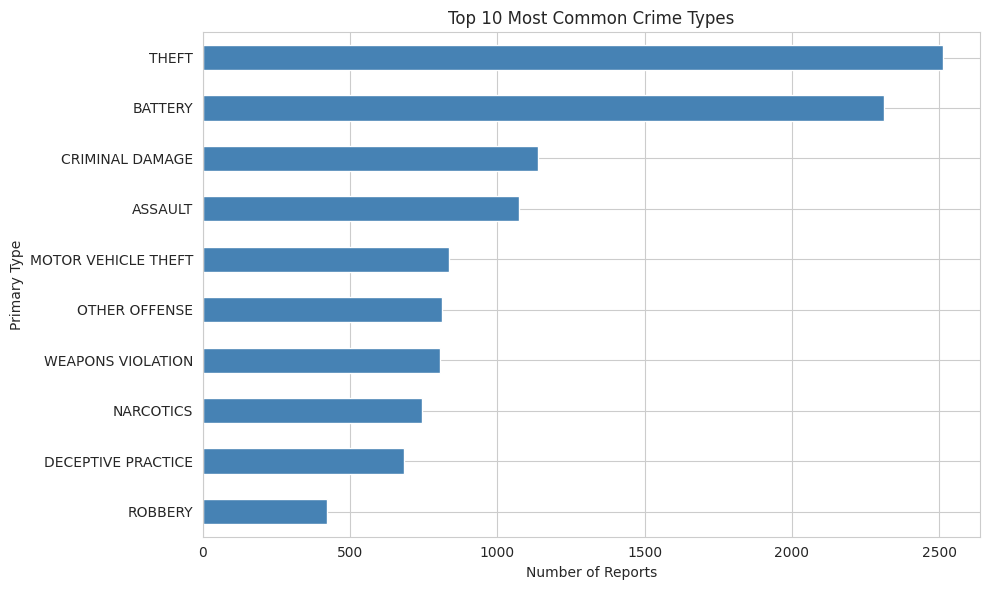

In [12]:
crime_counts = df['Primary Type'].value_counts()
print(f"Number of distinct crime types: {df['Primary Type'].nunique()}")
print(crime_counts.head(10))

plt.figure(figsize=(10,6))
crime_counts.head(10).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Number of Reports')
plt.title('Top 10 Most Common Crime Types')
plt.tight_layout()
plt.savefig('crime_type_dist.png', dpi=100)
plt.show()

### 4.2 Overall Arrest Rate

Overall Arrest Breakdown:
Arrest
False    66.47
True     33.53
Name: proportion, dtype: float64


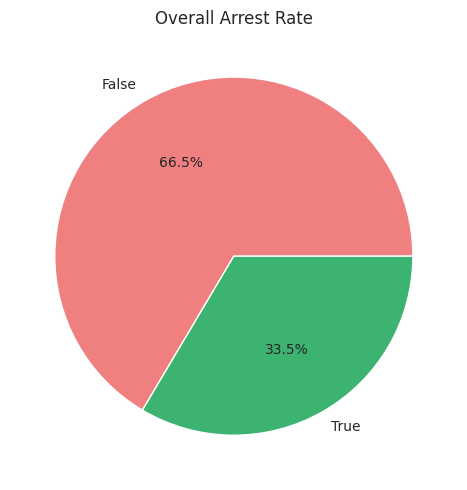

In [13]:
arrest_breakdown = df['Arrest'].value_counts(normalize=True) * 100
print("Overall Arrest Breakdown:")
print(arrest_breakdown.round(2))

plt.figure(figsize=(5,5))
arrest_breakdown.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral','mediumseagreen'], ylabel='')
plt.title('Overall Arrest Rate')
plt.tight_layout()
plt.savefig('arrest_rate_pie.png', dpi=100)
plt.show()

## 5. Bivariate Analysis

### 5.1 Arrest Rate by Crime Type

The overall arrest rate (33.5%) is a citywide average — it likely hides big differences between crime types. Crimes caught "in the act" (e.g. narcotics, weapons) should have much higher arrest rates than crimes reported after the fact (e.g. theft, burglary), where the offender is often long gone by the time police respond.

We restrict this to crime types with a reasonable sample size (at least 30 reports) so we're not drawing conclusions from 2-3 data points.

Primary Type
CONCEALED CARRY LICENSE VIOLATION    100.0
NARCOTICS                             98.3
INTERFERENCE WITH PUBLIC OFFICER      94.0
WEAPONS VIOLATION                     84.4
HOMICIDE                              74.5
PUBLIC PEACE VIOLATION                72.5
CRIMINAL TRESPASS                     54.2
OTHER OFFENSE                         39.2
BATTERY                               38.7
SEX OFFENSE                           31.7
OFFENSE INVOLVING CHILDREN            29.6
ASSAULT                               28.7
ROBBERY                               22.1
CRIMINAL SEXUAL ASSAULT               17.8
THEFT                                 16.1
BURGLARY                              16.1
CRIMINAL DAMAGE                       10.0
DECEPTIVE PRACTICE                     9.4
MOTOR VEHICLE THEFT                    9.0
Name: Arrest, dtype: float64


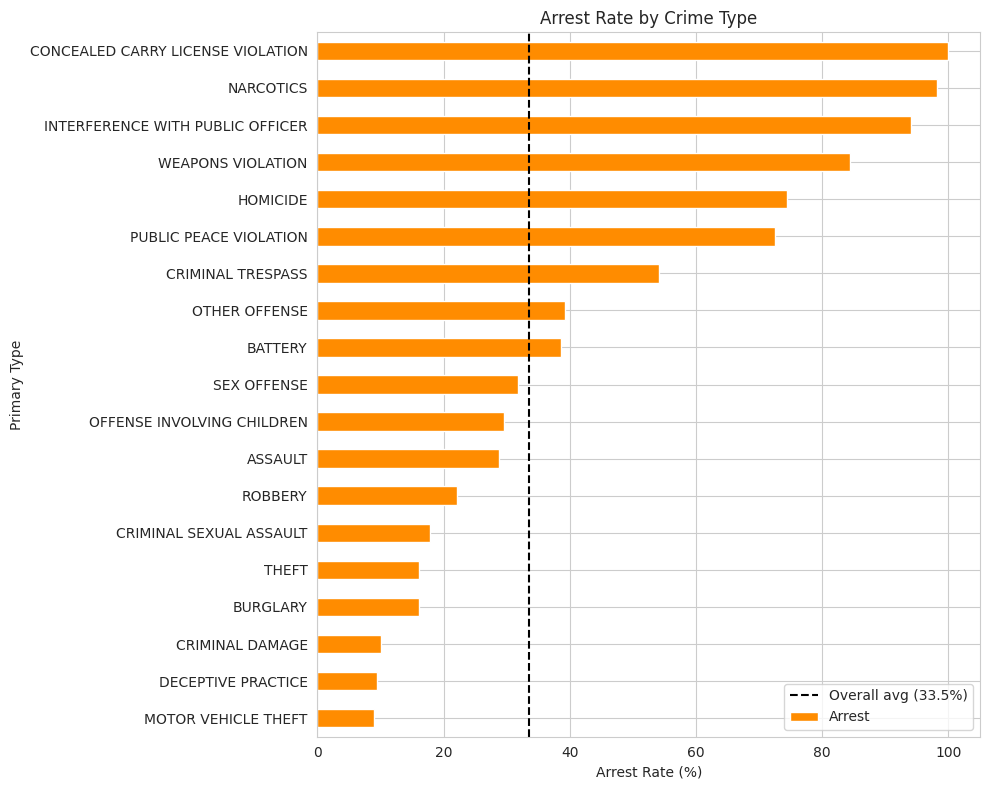

In [14]:
# Only look at crime types with enough volume to be meaningful
type_counts = df['Primary Type'].value_counts()
valid_types = type_counts[type_counts >= 30].index

arrest_by_type = df[df['Primary Type'].isin(valid_types)].groupby('Primary Type', observed=True)['Arrest'].mean() * 100
arrest_by_type = arrest_by_type.sort_values(ascending=False)

print(arrest_by_type.round(1))

plt.figure(figsize=(10,8))
arrest_by_type.sort_values().plot(kind='barh', color='darkorange')
plt.axvline(df['Arrest'].mean()*100, color='black', linestyle='--', label=f'Overall avg ({df["Arrest"].mean()*100:.1f}%)')
plt.xlabel('Arrest Rate (%)')
plt.title('Arrest Rate by Crime Type')
plt.legend()
plt.tight_layout()
plt.savefig('arrest_by_type.png', dpi=100)
plt.show()

### 5.2 Temporal Patterns

**Hypothesis to test:** crimes are expected to peak at night/early morning rather than broad daylight. Let's extract hour, day of week, and month from `Date` and check.

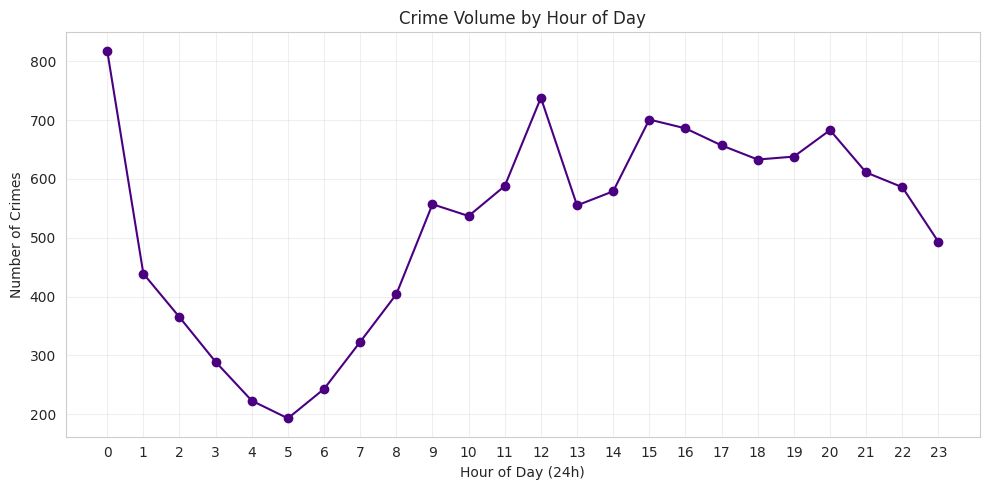

In [15]:
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()

hourly_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hourly_counts.plot(kind='line', marker='o', color='indigo')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Crimes')
plt.title('Crime Volume by Hour of Day')
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_crime.png', dpi=100)
plt.show()

**Investigating the two peaks:** midnight (hour 0) and noon (hour 12) are both elevated, but for possibly different reasons. Let's check whether the *same* crime types drive both peaks, or different ones.

In [16]:
midnight_crimes = df[df['Hour'] == 0]['Primary Type'].value_counts(normalize=True).head(5) * 100
noon_crimes = df[df['Hour'] == 12]['Primary Type'].value_counts(normalize=True).head(5) * 100

print("Top crime types AT MIDNIGHT (hour 0):")
print(midnight_crimes.round(1))
print("\nTop crime types AT NOON (hour 12):")
print(noon_crimes.round(1))

Top crime types AT MIDNIGHT (hour 0):
Primary Type
BATTERY               18.0
THEFT                 17.6
DECEPTIVE PRACTICE    13.0
CRIMINAL DAMAGE       12.0
OTHER OFFENSE          6.5
Name: proportion, dtype: float64

Top crime types AT NOON (hour 12):
Primary Type
THEFT                 21.5
BATTERY               13.8
DECEPTIVE PRACTICE    12.1
ASSAULT                8.9
NARCOTICS              8.8
Name: proportion, dtype: float64


**Insight:** Crime volume by hour shows two peaks — midnight (00:00, ~820 crimes) and noon (12:00, ~740 crimes) — with a clear trough between 3–6 AM.

At first glance this looks behavioral (e.g. "people are less alert at night/noon"), but breaking down crime type by hour tells a different story: the **same crime types** (`THEFT`, `BATTERY`, `DECEPTIVE PRACTICE`) dominate both peaks, rather than distinct crime types driving each one. This suggests the peaks are likely a **data logging artifact rather than a true behavioral spike** — when the exact time of a crime is unknown (common for theft/fraud discovered after the fact), records often default to a round hour like `00:00` or `12:00` instead of being left blank.

**Takeaway:** the 3–6 AM trough is a genuine, reliable signal (low activity overnight when the city is mostly asleep). The midnight/noon peaks should be interpreted cautiously — they likely reflect timestamp rounding/defaults for imprecise-time reports, not necessarily two literal moments where crime spikes.

### Day-of-Week Patterns

**Hypothesis:** weekdays (when homes/offices are empty during work hours) might see more theft/burglary/deceptive practice than weekends, when more people are around. Let's check both the overall day-of-week pattern and burglary specifically.

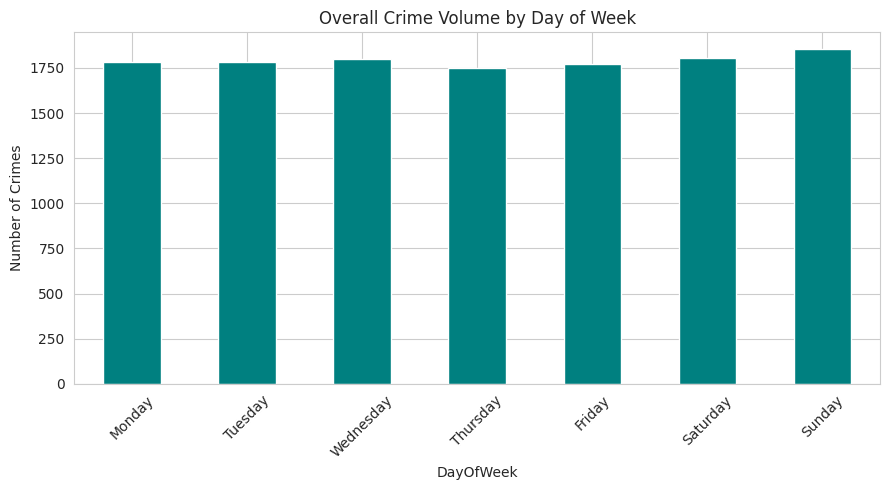

In [17]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_counts = df['DayOfWeek'].value_counts().reindex(day_order)

plt.figure(figsize=(9,5))
daily_counts.plot(kind='bar', color='teal')
plt.ylabel('Number of Crimes')
plt.title('Overall Crime Volume by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('daily_crime.png', dpi=100)
plt.show()

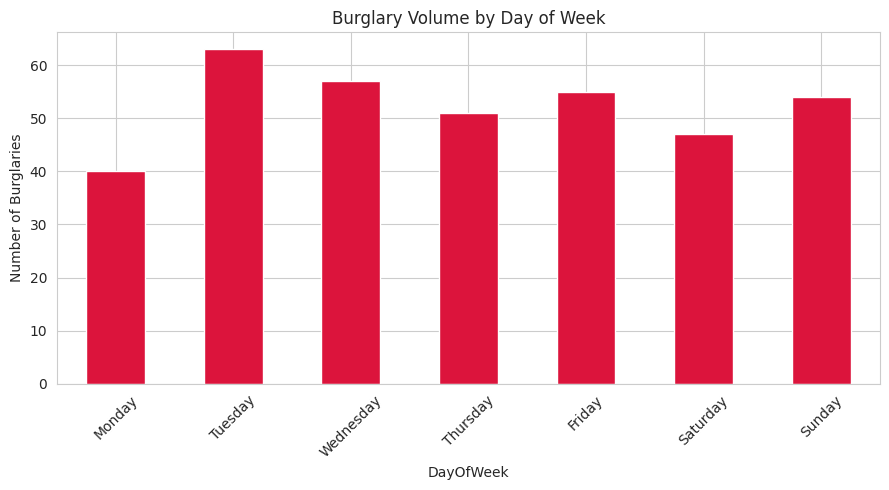

In [18]:
# Now check burglary specifically, since the hypothesis was crime-type-specific
burglary_daily = df[df['Primary Type']=='BURGLARY']['DayOfWeek'].value_counts().reindex(day_order)

plt.figure(figsize=(9,5))
burglary_daily.plot(kind='bar', color='crimson')
plt.ylabel('Number of Burglaries')
plt.title('Burglary Volume by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('burglary_daily.png', dpi=100)
plt.show()

## 6. Location-Based Patterns

**Hypothesis:** crime is concentrated in a handful of districts rather than evenly spread. Let's check the actual distribution, then look at what crime types dominate the top districts to reason about *why*, rather than speculate.

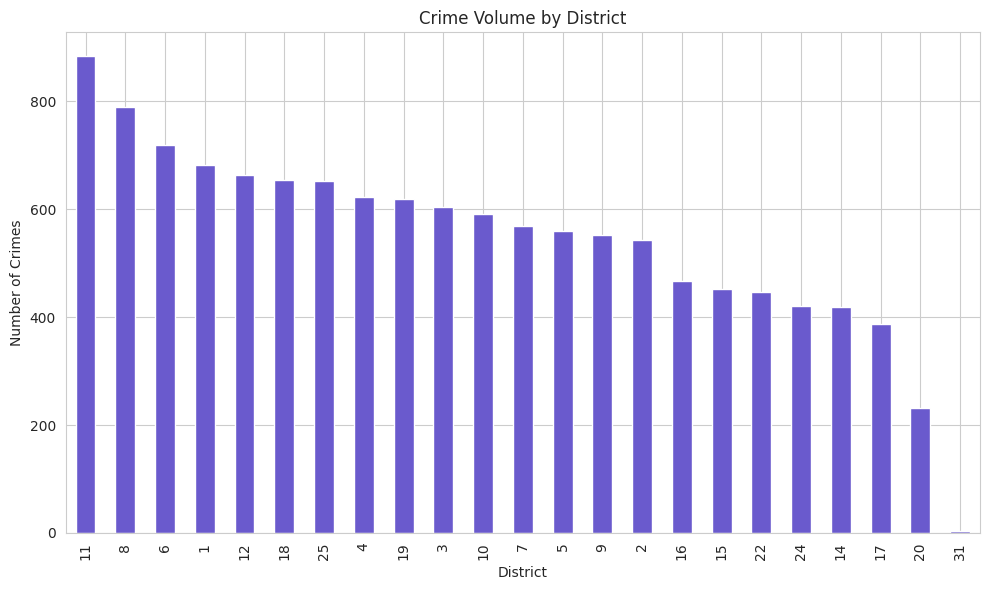

Top 3 districts account for 2393 crimes (19.1% of total)
Bottom 3 districts account for 622 crimes (5.0% of total)


In [19]:
district_counts = df['District'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
district_counts.plot(kind='bar', color='slateblue')
plt.xlabel('District')
plt.ylabel('Number of Crimes')
plt.title('Crime Volume by District')
plt.tight_layout()
plt.savefig('district_crime.png', dpi=100)
plt.show()

print(f"Top 3 districts account for {district_counts.head(3).sum()} crimes ({district_counts.head(3).sum()/len(df)*100:.1f}% of total)")
print(f"Bottom 3 districts account for {district_counts.tail(3).sum()} crimes ({district_counts.tail(3).sum()/len(df)*100:.1f}% of total)")

**Sanity check:** District 31 barely appears on the chart — worth confirming this is real before interpreting it.

In [20]:
print(df[df['District']==31].shape[0], "rows for District 31")
df[df['District']==31]

3 rows for District 31


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year,Hour,DayOfWeek,Month
5522,12753506,JF308249,2022-07-06 06:00:00,005XX W OHARE ST,820,THEFT,$500 AND UNDER,AIRPORT EXTERIOR - SECURE AREA,False,False,1653,31,41,76,6,1107552.0,1930183.0,2022,01/03/2023 3:40:27 PM,41.965057,-87.879953,"(41.965057367, -87.879953326)",2022,6,Wednesday,July
8350,12637539,JF168329,2022-03-09 14:07:00,039XX W CHICAGO AVE,810,THEFT,OVER $500,SMALL RETAIL STORE,True,False,1112,31,37,23,6,1124178.0,1931354.0,2022,02/28/2024 3:40:28 PM,41.968013,-87.818796,"(41.968013038, -87.818796103)",2022,14,Wednesday,March
11619,12804161,JF368783,2022-08-24 14:33:00,039XX W CHICAGO AVE,1200,DECEPTIVE PRACTICE,STOLEN PROPERTY BUY / RECEIVE / POSSESS,SMALL RETAIL STORE,True,False,1112,31,37,23,13,1124178.0,1931354.0,2022,06/01/2023 3:41:29 PM,41.968013,-87.818796,"(41.968013038, -87.818796103)",2022,14,Wednesday,August


**Why is District 11 the highest?** Rather than speculate, compare its crime-type mix against the citywide average — if it's dominated by narcotics/violent crime disproportionately, that points to different causes than if it's mostly theft (which would suggest high foot traffic/commercial activity instead).

In [21]:
top_district = district_counts.index[0]
d11_mix = df[df['District']==top_district]['Primary Type'].value_counts(normalize=True).head(5)*100
overall_mix = df['Primary Type'].value_counts(normalize=True).head(5)*100

comparison = pd.DataFrame({f'District {top_district} %': d11_mix, 'Citywide %': overall_mix}).round(1)
comparison

,District 11 %,Citywide %
Primary Type,,
ASSAULT,7.1,8.6
BATTERY,16.2,18.4
CRIMINAL DAMAGE,7.9,9.1
MOTOR VEHICLE THEFT,NaN,6.7
NARCOTICS,27.7,NaN
THEFT,NaN,20.0
WEAPONS VIOLATION,10.1,NaN


### Arrest Rate by District

**Hypothesis:** since District 11 is disproportionately narcotics-driven (98.3% arrest rate crime type), high-crime-volume districts might also show high arrest rates — the opposite of what you might naively expect ("more crime = police overwhelmed = fewer arrests").

In [22]:
district_arrest = df.groupby('District', observed=True)['Arrest'].mean() * 100
district_volume = df['District'].value_counts()

# Combine into one table, sorted by volume, exclude the empty District 31 category
combined = pd.DataFrame({'Crime Volume': district_volume, 'Arrest Rate %': district_arrest.round(1)})
combined = combined[combined['Crime Volume'] > 0].sort_values('Crime Volume', ascending=False)
print(combined)

# Correlation between volume and arrest rate
corr = combined['Crime Volume'].corr(combined['Arrest Rate %'])
print(f"\nCorrelation between crime volume and arrest rate: {corr:.2f}")

          Crime Volume  Arrest Rate %
District                             
11                 884           54.6
8                  789           30.0
6                  720           30.7
1                  683           40.6
12                 663           25.6
18                 655           33.7
25                 653           33.8
4                  622           24.8
19                 619           22.1
3                  604           30.8
10                 592           41.9
7                  570           37.5
5                  560           34.5
9                  553           35.4
2                  543           24.3
16                 468           32.9
15                 453           42.6
22                 447           31.5
24                 420           30.5
14                 419           26.3
17                 387           33.3
20                 232           24.6
31                   3           66.7

Correlation between crime volume and arrest rate:

**Insight:** Crime volume and arrest rate across districts are only weakly correlated (r = -0.23) — high-crime districts are **not** systematically more or less likely to see arrests. District 11 (highest volume) does have an above-average arrest rate (54.6%), but that's explained by its narcotics-heavy crime mix (established earlier), not by volume itself — District 19, with comparable volume, has one of the lowest arrest rates (22.1%).

**Takeaway for modeling (Task 2):** `District` alone is unlikely to be a strong predictor of arrest — `Primary Type` is the stronger driver. District may still add value as a secondary/interaction feature, but shouldn't be treated as a proxy for "how tough policing is" in that area.

## 7. Summary of Key Insights

**Data Quality**
- The dataset is structurally clean: no duplicate records, no `Year`/`Date` inconsistencies, no out-of-bounds coordinates or invalid dates.
- Missing data (coordinates, location description — ~1.4% of rows) is not random. It's concentrated in `NARCOTICS` and `DECEPTIVE PRACTICE` cases, likely because these crime types often lack a clean physical crime scene to geocode (fraud has no scene; narcotics is often logged at point of arrest).

**Crime Type & Arrest**
- `THEFT` and `BATTERY` dominate volume (~39% of all crime combined), but they are *not* the crimes most likely to end in arrest.
- Arrest rate varies enormously by crime type (9%–100%) and is driven by how a crime is typically discovered, not its severity: "contact" crimes caught in the act (`NARCOTICS` 98.3%, `WEAPONS VIOLATION` 84.4%) have very high arrest rates, while crimes reported after the fact (`MOTOR VEHICLE THEFT` 9.0%, `DECEPTIVE PRACTICE` 9.4%, `THEFT` 16.1%) have very low arrest rates.
- This makes `Primary Type` likely the single strongest predictive feature for Task 2.

**Temporal Patterns**
- Overall crime dips sharply between 3–6 AM (city mostly asleep) — a genuine, reliable signal.
- The apparent "peaks" at midnight and noon are largely a data-logging artifact: crimes with imprecise/unknown timestamps (theft, fraud) tend to default to round hours like 00:00/12:00, rather than reflecting a true behavioral spike at those exact times.
- Day-of-week shows almost no variation in overall crime volume — but burglary specifically peaks mid-week (Tue–Wed) and dips on Monday/Saturday, consistent with homes being empty during the work week.

**Location Patterns**
- Crime is moderately concentrated: the top 3 districts account for ~19% of citywide crime, vs. ~5% for the bottom 3 — a gradual concentration, not an extreme one.
- District 11 (highest volume) has a crime-type profile skewed heavily toward `NARCOTICS` (27.7% vs. ~6% citywide) and `WEAPONS VIOLATION`, rather than `THEFT` — suggesting concentrated drug-market activity rather than generic high-foot-traffic opportunistic crime.
- Crime volume and arrest rate by district are only weakly correlated (r = -0.23) — a district's arrest rate is driven more by *what kind* of crime happens there than by *how much* crime happens there.

**Implications for Task 2 (ML Model)**
- `Primary Type` is expected to be the strongest single predictor of arrest.
- `Hour`/time features should be engineered carefully — the midnight/noon artifact means raw hour may need binning (e.g., "known precise time" vs "rounded/default time") rather than being used naively.
- `District` may add some predictive value but should not be treated as a standalone proxy for arrest likelihood — its effect is likely mediated by crime type.

# Task 2: Machine Learning Model Development

**Objective:** Predict whether a reported crime results in an arrest (`Arrest`: True/False), using insights from the EDA above to guide feature engineering.

## 1. Feature Selection & Engineering

**Dropped:** `ID`, `Case Number`, `Updated On`, `Location`, `X Coordinate`, `Y Coordinate`, `Description` (too high-cardinality; `Primary Type` already captures the category), `Latitude`/`Longitude` (redundant with `District` for this purpose).

**Dropped for redundancy:** `Ward`, `Beat`, `Community Area` — all encode the same underlying geography as `District` at different granularities. Keeping all four would inflate dimensionality and dilute the location signal across correlated columns without adding new information. `District` is kept since it was already explored in depth during EDA.

**Kept / engineered features:**
- `Primary Type` — strongest predictor per EDA (arrest rate ranges 9%-100% across types)
- `District` — location signal, though EDA showed its effect is mediated by crime type
- `Domestic` — boolean flag, plausible link to arrest (domestic incidents often have police present)
- `Hour` — engineered from `Date`; EDA showed a genuine overnight trough
- `DayOfWeek` — engineered from `Date`
- `Month` — captures any seasonal effect
- `Location Description` — where the crime occurred (street, residence, store, etc.)

**Target:** `Arrest` (boolean)

In [23]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

features = ['Primary Type', 'District', 'Domestic', 'Hour', 'DayOfWeek', 'Month', 'Location Description']
target = 'Arrest'

model_df = df[features + [target]].copy()
model_df = model_df.dropna(subset=features)  # District has no nulls, but safe guard
print(f"Modeling dataset shape: {model_df.shape}")
model_df[target].value_counts(normalize=True)

Modeling dataset shape: (12539, 8)


Arrest
False    0.664726
True     0.335274
Name: proportion, dtype: float64

**Note on class balance:** the target is moderately imbalanced (66.5% No-Arrest / 33.5% Arrest) — not extreme, but enough that raw accuracy alone would be misleading (predicting "No Arrest" every time scores 66.5% accuracy while being useless). We use a **stratified split** to preserve this ratio in both train/test sets, and lean on precision/recall/F1/ROC-AUC rather than accuracy alone.

In [24]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train arrest rate: {y_train.mean():.3f} | Test arrest rate: {y_test.mean():.3f}")

Train: (10031, 7), Test: (2508, 7)
Train arrest rate: 0.335 | Test arrest rate: 0.335


**Preprocessing:** all our features are categorical (or boolean/numeric-but-cyclical, like `Hour`). We one-hot encode the categorical columns and pass `Domestic`/`Hour` through, wrapped in a pipeline so preprocessing is learned only on training data (avoiding leakage from the test set into encoding).

In [25]:
categorical_features = ['Primary Type', 'District', 'DayOfWeek', 'Month', 'Location Description']
passthrough_features = ['Domestic', 'Hour']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
], remainder='passthrough')

print("Preprocessor ready.")

Preprocessor ready.


## 2. Model Building

Two models, chosen for contrast:
- **Logistic Regression** — simple, interpretable linear baseline
- **Random Forest** — handles non-linear feature interactions (e.g. the `Primary Type` × `District` interaction we found in EDA), likely to perform better on this kind of categorical, interaction-heavy data

In [26]:
log_reg = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

rf = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
])

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Both models trained.")

Both models trained.


## 3. Model Evaluation

Given the class imbalance (33.5% positive class), we report **precision, recall, F1-score, and ROC-AUC** in addition to accuracy — accuracy alone would be misleading since a trivial "always predict No Arrest" model scores 66.5%.

In [27]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=['No Arrest','Arrest']))
    print(f"ROC-AUC: {roc_auc_score(y_test, probs):.3f}")
    print()
    return preds

log_reg_preds = evaluate("Logistic Regression", log_reg, X_test, y_test)
rf_preds = evaluate("Random Forest", rf, X_test, y_test)

=== Logistic Regression ===
              precision    recall  f1-score   support

   No Arrest       0.79      0.93      0.85      1667
      Arrest       0.78      0.51      0.62       841

    accuracy                           0.79      2508
   macro avg       0.79      0.72      0.74      2508
weighted avg       0.79      0.79      0.78      2508

ROC-AUC: 0.845

=== Random Forest ===
              precision    recall  f1-score   support

   No Arrest       0.76      0.98      0.86      1667
      Arrest       0.91      0.40      0.55       841

    accuracy                           0.78      2508
   macro avg       0.84      0.69      0.71      2508
weighted avg       0.81      0.78      0.76      2508

ROC-AUC: 0.852



**Reading the results:** Random Forest has a slightly higher ROC-AUC (0.852 vs 0.845) and much higher precision on the Arrest class (0.91 vs 0.78), but Logistic Regression has notably better recall (0.51 vs 0.40) and F1-score (0.62 vs 0.55) for Arrest. Neither model is a clear winner on a single 80/20 split — this is exactly why k-fold cross-validation matters: it checks whether this pattern is stable, or just an artifact of this particular train/test split.

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_scores = cross_val_score(log_reg, X, y, cv=cv, scoring='roc_auc')
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print(f"Logistic Regression - ROC-AUC per fold: {log_reg_scores.round(3)}")
print(f"Logistic Regression - Mean: {log_reg_scores.mean():.3f} (+/- {log_reg_scores.std():.3f})")
print()
print(f"Random Forest - ROC-AUC per fold: {rf_scores.round(3)}")
print(f"Random Forest - Mean: {rf_scores.mean():.3f} (+/- {rf_scores.std():.3f})")

Logistic Regression - ROC-AUC per fold: [0.848 0.823 0.849 0.846 0.843]
Logistic Regression - Mean: 0.842 (+/- 0.010)

Random Forest - ROC-AUC per fold: [0.854 0.832 0.853 0.851 0.86 ]
Random Forest - Mean: 0.850 (+/- 0.009)


## 4. Final Model Selection

**Random Forest is selected as the final model.**

**Justification:**
- Random Forest consistently outperforms Logistic Regression on ROC-AUC across all 5 CV folds (mean 0.850 vs 0.842), with comparably low variance (~0.01 for both) — confirming this is a stable advantage, not a one-off split artifact.
- ROC-AUC is the right primary metric here since it evaluates ranking quality across all classification thresholds, which matters given our imbalanced target — it isn't sensitive to the specific 0.5 cutoff the way accuracy is.
- Random Forest is also better suited to this feature set: our EDA repeatedly found **interaction effects** (e.g. District's arrest rate is mediated by its crime-type mix, not a standalone effect) — tree-based models capture such non-linear interactions naturally, while Logistic Regression assumes a linear, additive relationship between features and the log-odds of arrest unless interaction terms are manually engineered.

**Trade-off to note:** Logistic Regression has a notably higher recall on the Arrest class in the single-split test (0.51 vs 0.40). If the priority were "catch as many true arrests as possible" (e.g. for a use case sensitive to missed positives), Logistic Regression — or a Random Forest with an adjusted classification threshold — would be worth reconsidering instead of optimizing for ROC-AUC alone.